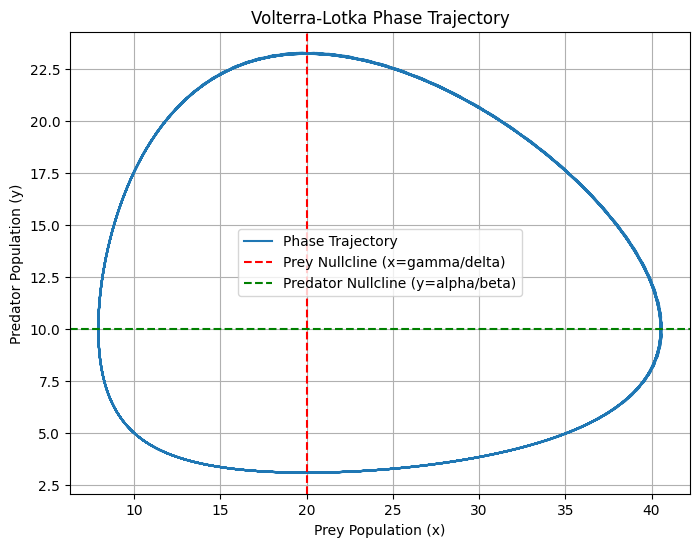

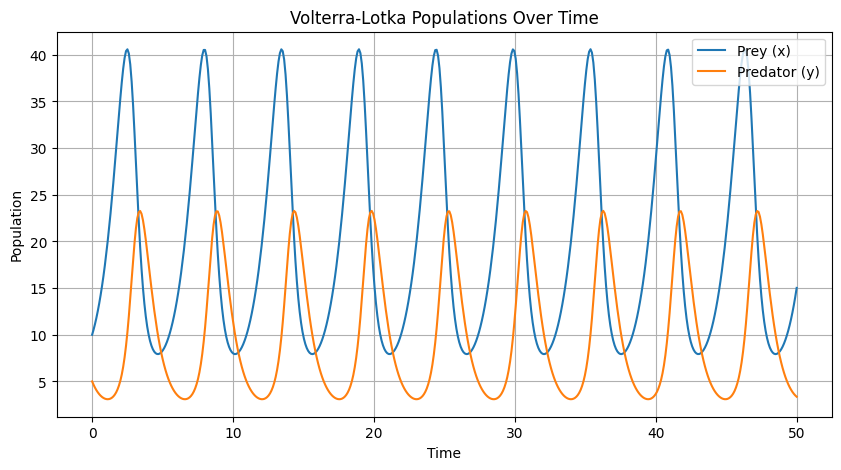

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the Volterra-Lotka ODE system
def volterra_lotka(X, t, alpha, beta, delta, gamma):
    x, y = X
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

# Parameters
alpha = 1.0  # Prey growth rate
beta = 0.1   # Prey predation rate
delta = 0.075 # Predator growth rate per prey
gamma = 1.5  # Predator death rate

# Initial conditions (prey, predator)
x0 = 10.0
y0 = 5.0
X0 = [x0, y0]

# Time points for integration
t = np.linspace(0, 50, 500)

# Solve the ODE
sol = odeint(volterra_lotka, X0, t, args=(alpha, beta, delta, gamma))

# Extract prey and predator populations
prey = sol[:, 0]
predator = sol[:, 1]

# Plot the phase trajectory
plt.figure(figsize=(8, 6))
plt.plot(prey, predator, label='Phase Trajectory')
plt.xlabel('Prey Population (x)')
plt.ylabel('Predator Population (y)')
plt.title('Volterra-Lotka Phase Trajectory')
plt.grid(True)
plt.axvline(x=gamma/delta, color='r', linestyle='--', label='Prey Nullcline (x=gamma/delta)')
plt.axhline(y=alpha/beta, color='g', linestyle='--', label='Predator Nullcline (y=alpha/beta)')
plt.legend()
plt.show()

# Optionally, plot populations over time
plt.figure(figsize=(10, 5))
plt.plot(t, prey, label='Prey (x)')
plt.plot(t, predator, label='Predator (y)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Volterra-Lotka Populations Over Time')
plt.legend()
plt.grid(True)
plt.show()


DAG visualization saved as volterra_lotka_dag.png


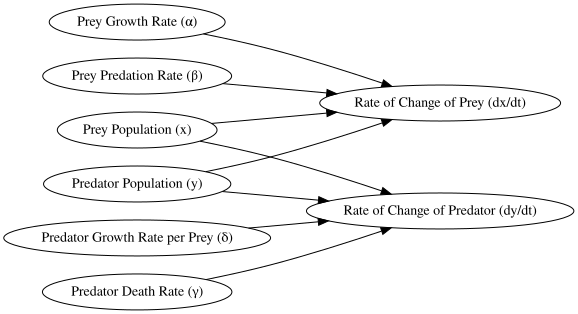

In [1]:
import graphviz

# Create a new directed graph
dot = graphviz.Digraph(comment='Volterra-Lotka Causal Model', graph_attr={'rankdir': 'LR'})

# Add nodes for variables and parameters
dot.node('x', 'Prey Population (x)')
dot.node('y', 'Predator Population (y)')
dot.node('alpha', 'Prey Growth Rate (α)')
dot.node('beta', 'Prey Predation Rate (β)')
dot.node('delta', 'Predator Growth Rate per Prey (δ)')
dot.node('gamma', 'Predator Death Rate (γ)')

# Add nodes for rates of change
dot.node('dxdt', 'Rate of Change of Prey (dx/dt)')
dot.node('dydt', 'Rate of Change of Predator (dy/dt)')

# Add edges based on causal relationships for dxdt
dot.edge('alpha', 'dxdt')
dot.edge('x', 'dxdt')
dot.edge('beta', 'dxdt')
dot.edge('y', 'dxdt')

# Add edges based on causal relationships for dydt
dot.edge('delta', 'dydt')
dot.edge('x', 'dydt')
dot.edge('y', 'dydt')
dot.edge('gamma', 'dydt')

# Render the graph
dot.render('volterra_lotka_dag', view=False, format='png', cleanup=True) # Saves to 'volterra_lotka_dag.png'

print("DAG visualization saved as volterra_lotka_dag.png")
# Display the DAG within the notebook (requires the graphviz executable to be installed and in PATH)
dot


# Task
Summarize the conceptual Directed Acyclic Graph (DAG) structure for the Volterra-Lotka equations by identifying its nodes (variables `x`, `y`, and parameters `alpha`, `beta`, `delta`, `gamma`) and the causal relationships represented by its edges, which determine the rates of change (`dxdt`, `dydt`).

## Identify Variables and Parameters

### Subtask:
List all relevant variables (prey population 'x', predator population 'y') and parameters (prey growth rate 'alpha', prey predation rate 'beta', predator growth rate per prey 'delta', predator death rate 'gamma') from the Volterra-Lotka equations. These will form the nodes of the DAG.


### Identified Variables and Parameters for the DAG Nodes

Based on the Volterra-Lotka equations provided in the code, the relevant variables and parameters are:

#### Variables (Populations):
*   **x**: Prey Population
*   **y**: Predator Population

#### Parameters:
*   **alpha**: Prey growth rate
*   **beta**: Prey predation rate
*   **delta**: Predator growth rate per prey
*   **gamma**: Predator death rate

These variables and parameters will serve as the initial set of nodes for constructing the Directed Acyclic Graph (DAG) for the Volterra-Lotka model.

In [2]:
import numpy as np
from scipy.integrate import odeint

# Define the Volterra-Lotka ODE system, as identified in the DAG
def volterra_lotka(X, t, alpha, beta, delta, gamma):
    x, y = X
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

# Parameters (nodes in our DAG)
alpha = 1.0  # Prey growth rate
beta = 0.1   # Prey predation rate
delta = 0.075 # Predator growth rate per prey
gamma = 1.5  # Predator death rate

# Initial conditions
x0 = 10.0
y0 = 5.0
X0 = [x0, y0]

# Time points for integration
t = np.linspace(0, 50, 500)

# Solve the ODE using the defined parameters
sol = odeint(volterra_lotka, X0, t, args=(alpha, beta, delta, gamma))

# Extract prey and predator populations from the simulation results
prey_simulated = sol[:, 0]
predator_simulated = sol[:, 1]

print("ODE simulation complete. Simulated prey and predator populations are stored in 'prey_simulated' and 'predator_simulated'.")


ODE simulation complete. Simulated prey and predator populations are stored in 'prey_simulated' and 'predator_simulated'.


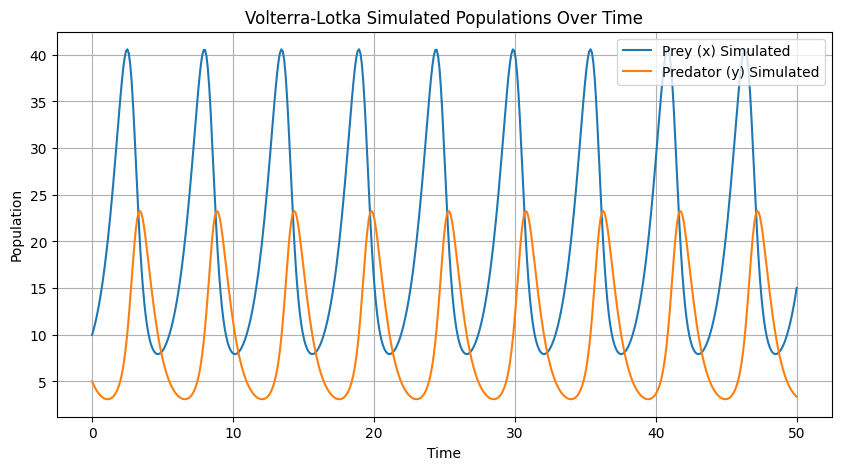

In [4]:
import matplotlib.pyplot as plt

# Assuming t, prey_simulated, and predator_simulated are available from previous execution

plt.figure(figsize=(10, 5))
plt.plot(t, prey_simulated, label='Prey (x) Simulated')
plt.plot(t, predator_simulated, label='Predator (y) Simulated')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Volterra-Lotka Simulated Populations Over Time')
plt.legend()
plt.grid(True)
plt.show()


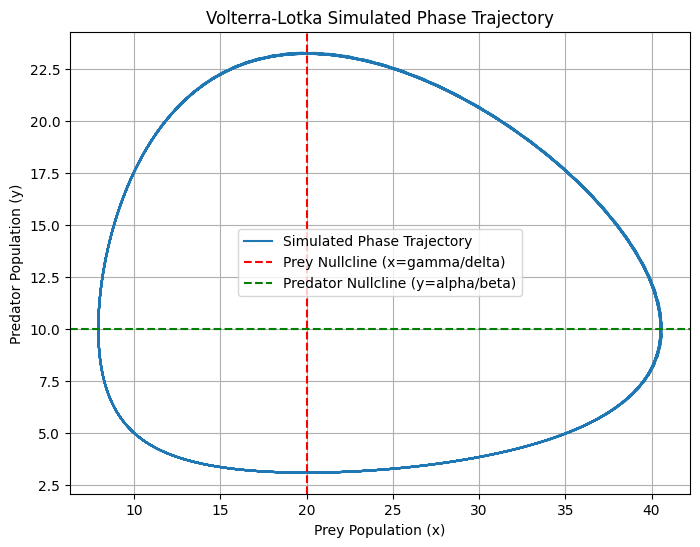

In [3]:
import matplotlib.pyplot as plt

# Assuming prey_simulated and predator_simulated are available from previous execution
# If not, you would need to run the ODE simulation cell first.

plt.figure(figsize=(8, 6))
plt.plot(prey_simulated, predator_simulated, label='Simulated Phase Trajectory')
plt.xlabel('Prey Population (x)')
plt.ylabel('Predator Population (y)')
plt.title('Volterra-Lotka Simulated Phase Trajectory')
plt.grid(True)

# Add nullclines for reference, if parameters are still in scope
# (alpha, beta, delta, gamma from previous cells)
# To ensure nullclines are available, you might consider passing them or defining them locally.
# For this visualization, I'll assume they are still accessible from the global scope.

# Re-define parameters if not in global scope or to ensure they are correct for the plot
alpha = 1.0  # Prey growth rate
beta = 0.1   # Prey predation rate
delta = 0.075 # Predator growth rate per prey
gamma = 1.5  # Predator death rate

plt.axvline(x=gamma/delta, color='r', linestyle='--', label='Prey Nullcline (x=gamma/delta)')
plt.axhline(y=alpha/beta, color='g', linestyle='--', label='Predator Nullcline (y=alpha/beta)')

plt.legend()
plt.show()


You can now use `prey_simulated` and `predator_simulated` for further analysis or visualization, similar to how they were plotted in the initial visualization cell.

## Determine Causal Relationships for Rates of Change

### Subtask:
Analyze the Volterra-Lotka differential equations (`dxdt = alpha * x - beta * x * y` and `dydt = delta * x * y - gamma * y`) to identify direct causal influences. For instance, 'alpha', 'x', 'beta', and 'y' directly influence 'dxdt'. Similarly, 'delta', 'x', 'gamma', and 'y' directly influence 'dydt'. These influences will be represented as directed edges.


### Causal Relationships in Volterra-Lotka Equations

Let's analyze the direct causal influences for the rates of change, `dxdt` and `dydt`, based on the provided Volterra-Lotka differential equations.

#### 1. Analysis of `dxdt` (Rate of change for Prey Population)

The equation for `dxdt` is given by: `dxdt = alpha * x - beta * x * y`

From this equation, the variables and parameters that directly influence `dxdt` are:
*   `alpha`: The prey growth rate, directly affecting the positive growth term.
*   `x`: The current prey population, involved in both the growth and predation terms.
*   `beta`: The prey predation rate, determining the impact of predator-prey encounters.
*   `y`: The current predator population, involved in the predation term.

Therefore, we can establish the following directed edges for `dxdt`:
*   `alpha` -> `dxdt`
*   `x` -> `dxdt`
*   `beta` -> `dxdt`
*   `y` -> `dxdt`

#### 2. Analysis of `dydt` (Rate of change for Predator Population)

The equation for `dydt` is given by: `dydt = delta * x * y - gamma * y`

From this equation, the variables and parameters that directly influence `dydt` are:
*   `delta`: The predator growth rate per prey consumed, affecting the positive growth term.
*   `x`: The current prey population, involved in the predator growth term.
*   `y`: The current predator population, involved in both the growth and death terms.
*   `gamma`: The predator death rate, directly affecting the negative death term.

Therefore, we can establish the following directed edges for `dydt`:
*   `delta` -> `dydt`
*   `x` -> `dydt`
*   `y` -> `dydt`
*   `gamma` -> `dydt`

These direct influences form the basis of the causal relationships and would be represented as directed edges in a conceptual Directed Acyclic Graph (DAG) for the system.

## Describe the Conceptual DAG Structure

### Subtask:
Based on the identified variables/parameters and their causal relationships, describe the structure of the Direct Acyclic Graph. The nodes will include the populations (x, y), parameters (alpha, beta, delta, gamma), and the rates of change (dxdt, dydt). Edges will flow from the influencing variables/parameters to the rates of change. For a strict DAG, we consider the instantaneous causality, where current populations and parameters cause the rates of change, rather than cyclic dynamic feedback over time.


### Conceptual DAG Structure of the Volterra-Lotka Model

To understand the instantaneous causal relationships within the Volterra-Lotka system, we can conceptualize it as a Directed Acyclic Graph (DAG) for a given moment in time. This DAG illustrates how the current state variables and parameters influence the instantaneous rates of change.

#### 1. Nodes of the DAG
The nodes in our conceptual DAG represent the key components of the Volterra-Lotka model:
*   **Population Variables:**
    *   `x`: Prey Population
    *   `y`: Predator Population
*   **Model Parameters:**
    *   `alpha`: Prey Growth Rate
    *   `beta`: Prey Predation Rate
    *   `delta`: Predator Growth Rate per Prey
    *   `gamma`: Predator Death Rate
*   **Rates of Change (Dependent Variables):**
    *   `dxdt`: Rate of Change of Prey Population
    *   `dydt`: Rate of Change of Predator Population

#### 2. Directed Edges of the DAG
Edges in the DAG represent direct causal influence. An edge from node A to node B (`A -> B`) indicates that A directly influences B. Based on the Volterra-Lotka equations:

**Equation for `dxdt`:** `dxdt = alpha * x - beta * x * y`
*   `alpha` -> `dxdt` (Prey growth rate directly influences prey population change)
*   `x` -> `dxdt` (Current prey population directly influences prey population change)
*   `beta` -> `dxdt` (Prey predation rate directly influences prey population change)
*   `y` -> `dxdt` (Current predator population directly influences prey population change via predation)

**Equation for `dydt`:** `dydt = delta * x * y - gamma * y`
*   `delta` -> `dydt` (Predator growth rate per prey directly influences predator population change)
*   `x` -> `dydt` (Current prey population directly influences predator population change via availability)
*   `y` -> `dydt` (Current predator population directly influences predator population change, both growth from prey and death)
*   `gamma` -> `dydt` (Predator death rate directly influences predator population change)

#### 3. Acyclic Nature of the Conceptual DAG
This conceptual DAG is *acyclic* because it represents instantaneous causality at a single point in time. It shows how the current values of `x`, `y`, `alpha`, `beta`, `delta`, and `gamma` determine the *current* rates of change, `dxdt` and `dydt`.

Crucially, `dxdt` and `dydt` are considered *effects* in this DAG; they do not cause `x` or `y` in an instantaneous sense. The full dynamic system *does* involve feedback loops over time (e.g., `dxdt` influences `x` in the next time step, which then influences `dydt`), but this DAG specifically abstracts away the temporal dimension to focus on the immediate dependencies. If we were to include `x` and `y` at `t+dt` as nodes, we would introduce cycles. However, by strictly considering the current state and parameters determining the current rates of change, we maintain an acyclic structure where `dxdt` and `dydt` are terminal nodes influenced by everything else, but not influencing anything themselves within this specific instantaneous causal graph.

## Final Task

### Subtask:
Summarize the conceptual DAG structure for the Volterra-Lotka Equation, explaining its nodes and edges as derived from the equations.


## Summary:

### Data Analysis Key Findings

*   **Identified Nodes:** The conceptual DAG for the Volterra-Lotka equations comprises the following nodes:
    *   **Population Variables:** Prey population (`x`) and Predator population (`y`).
    *   **Model Parameters:** Prey growth rate (`alpha`), Prey predation rate (`beta`), Predator growth rate per prey (`delta`), and Predator death rate (`gamma`).
    *   **Rates of Change:** Rate of change of prey population (`dxdt`) and Rate of change of predator population (`dydt`).
*   **Established Directed Edges (Causal Relationships):**
    *   **For `dxdt`:** The rate of change of prey population is directly influenced by `alpha`, `x`, `beta`, and `y`. This is represented by edges: `alpha` -> `dxdt`, `x` -> `dxdt`, `beta` -> `dxdt`, and `y` -> `dxdt`.
    *   **For `dydt`:** The rate of change of predator population is directly influenced by `delta`, `x`, `y`, and `gamma`. This is represented by edges: `delta` -> `dydt`, `x` -> `dydt`, `y` -> `dydt`, and `gamma` -> `dydt`.
*   **Acyclic Nature:** The conceptual DAG is inherently acyclic because it represents instantaneous causality at a single point in time. The rates of change (`dxdt`, `dydt`) are considered effects of the current state variables and parameters, and do not instantaneously cause `x` or `y` within this specific causal structure.

### Insights or Next Steps

*   This conceptual DAG provides a clear, instantaneous view of the causal dependencies within the Volterra-Lotka model, which is foundational for understanding the underlying mechanisms that drive population dynamics.
*   To extend this static causal understanding into a full dynamic model, one could consider constructing a Dynamic Bayesian Network (DBN) or a time-series DAG, where `x` and `y` at time `t` would influence `x` and `y` at time `t+1` via the calculated rates of change.
